# YOLOv3 — Redmon & Farhadi (2018), explained

Paper: *YOLOv3: An Incremental Improvement*.

Goal of this notebook: **understand what YOLOv3 changed relative to YOLOv1 (`n5`), and why each
change was made** — not to build a framework. Anything PyTorch already provides is used as-is.
Same dataset as `n5`: tiger detection on [ATRW](https://cvwc2019.github.io/challenge.html).

## How we got here: v1 → v2 → v3

The paper opens by saying it "mostly took good ideas from other people" — specifically its own
predecessor, YOLO9000/YOLOv2. Since this series only has notebooks for v1 and v3, here's the
missing middle step, so the jump doesn't look arbitrary:

| Version | What it added | Problem it fixed | Benefit |
|---|---|---|---|
| **YOLOv1** (`n5`) | Each grid cell regresses a box **from scratch**: raw $(x,y,w,h)$, single 7×7 scale, whichever of B raw predictors has highest IOU with the ground truth "wins" | — | simple, fast — but the network has to learn box shapes with no starting point, and one scale can't represent both a full-frame tiger and a distant, small one |
| **YOLOv2 / YOLO9000** | **Anchor boxes**: k-means on the *training set's own box shapes* gives a handful of "typical" box priors; the network now predicts small **offsets from a prior** ($t_x,t_y,t_w,t_h$) instead of a box from nothing. $\sigma(t_x)+c_x$ keeps the center inside its cell. Darknet-19 backbone, batchnorm on every conv. | v1's unconstrained regression target was hard to fit and unstable | Faster convergence, much better recall — the network refines a plausible box instead of inventing one |
| **YOLOv3 (this notebook)** | Keeps v2's anchor parametrization exactly, and adds: **(a)** a much deeper backbone, **Darknet-53**, using the residual shortcuts from `n4`'s ResNet; **(b)** prediction at **3 scales** (13×13, 26×26, 52×52 for a 416 input) via upsample-and-concatenate with earlier feature maps — the same idea as a feature pyramid network; **(c)** **independent logistic classifiers + binary cross-entropy** instead of softmax, so a box can carry multiple labels; **(d)** objectness is its own logistic target, matched to whichever anchor best overlaps the ground truth, with a "don't-care" band for near-miss anchors | v2's single 13×13 scale still missed small or tightly clustered objects; Darknet-19 was shallower than the best classifiers of the day; softmax assumes one label per box | Paper reports a **reversal** of YOLO's historic weakness on small objects, thanks to the 3-scale design; Darknet-53 matches ResNet-152 accuracy at roughly 2× the speed (paper Table 2) |

**What the paper tried and dropped** (Sec 4 of the paper — worth knowing, because it explains
choices below that might otherwise look arbitrary):
- **Linear activation for the $x,y$ offset** (instead of sigmoid) — "decreased model stability."
  We use sigmoid for exactly the reason v1 needed one bolted on in `n5`.
- **Focal loss** — cost 2 mAP; YOLO's separate objectness/class terms already address the
  foreground/background imbalance focal loss targets.
- **Faster R-CNN-style dual IOU thresholds** for assigning positive/negative anchors — "couldn't
  get good results." We use the paper's actual mechanism (best-IOU anchor is positive, anchors
  with IOU > 0.5 that aren't the best are ignored, everything else is negative) instead.

**Layout** (same six sections as every notebook in this series)
1. Load the data
2. Helper functions, and why each one exists
3. The architecture — anchors, scales, Darknet-53, and the training step line by line
4. Train
5. Predict and validate
6. Glossary

**What the paper specifies** (kept): the anchor-relative box equations
$b_x=\sigma(t_x)+c_x,\ b_y=\sigma(t_y)+c_y,\ b_w=p_we^{t_w},\ b_h=p_he^{t_h}$; sum-squared error on
the box terms; binary cross-entropy (logistic) for objectness and class; the best-IOU-anchor
assignment rule with an ignore band; k-means (IOU-distance) anchor priors; 3-scale prediction via
upsample + concatenate; leaky ReLU(0.1) throughout; residual shortcuts in the backbone.

**Where this adapts** (same three reasons as `n5`, plus one new one):
- C=1 (**Tiger** only), same as `n5` — mAP collapses to AP for "Tiger."
- No ImageNet pretraining — trained end-to-end from random init.
- Darknet-53 has 53 conv layers in stages of [1,2,8,8,4] residual blocks; we use the same
  stride/channel progression with fewer repeats, **[1,1,2,2,1]** — call it **MiniDarknet53** — same
  scale-down trade-off as Fast YOLO in `n5` and ResNet-18 in `n4`.
- Anchors are computed by k-means on **ATRW's own box shapes**, not COCO's 9 clusters — the paper
  does this per-dataset too ("we just sort of chose 9 clusters... on the COCO dataset the 9
  clusters were..."), so a tiger-specific set is actually more faithful to the paper's method, not
  less.


# Section 1 — Loading the data

Same ATRW detection split as `n5` (2,762 labelled frames, up to 10 tigers each, `train`/`val` ids
from `ImageSets/Main/`) — see `n5` Section 1 for the full directory layout. Two things differ here:

- **Image size**: 416×416, not 448×448. This is the canonical YOLOv3 size — it divides evenly by
  32, giving the classic 13/26/52 grids the three detection heads use.
- **The target is no longer one grid.** Instead of "the cell containing the box center is
  responsible" (`n5`), a box now picks **one (scale, anchor) pair** — whichever of the 9 anchor
  priors best matches its shape — and only *that* cell, at *that* scale, gets a positive target.
  Every other anchor at every scale is a negative (or, if it happens to overlap the box by more
  than 0.5 IOU without being the best match, an *ignored* prediction — paper Sec 2.1).


In [1]:
p = 1

In [2]:
import os
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import torch
from torch import nn
from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

torch.manual_seed(0)
random.seed(0)

DATA_ROOT = Path("benchmarks/atrw_dataset_detection_tiger")
IMG_DIR = DATA_ROOT / "trainval"
ANN_DIR = DATA_ROOT / "Annotations"
SPLIT_DIR = DATA_ROOT / "ImageSets" / "Main"

CLASSES = ["Tiger"]
N_CLASSES = len(CLASSES)

print("torch", torch.__version__, "| device:", DEVICE)


torch 2.12.1+cu126 | device: cuda


In [3]:
IMG_SIZE = 416
A, C = 3, N_CLASSES                 # 3 anchors per scale, 1 class ("Tiger")
GRID_SIZES = [13, 26, 52]           # coarse (large objects) -> fine (small objects)
STRIDES = [32, 16, 8]               # pixels per cell at each scale


def read_split(name):
    """train / val / trainval -> list of image ids, e.g. '0131'."""
    with open(SPLIT_DIR / f"{name}.txt") as f:
        return [line.strip() for line in f if line.strip()]


def parse_boxes(image_id):
    """Annotation XML -> (list of (xmin,ymin,xmax,ymax), orig_w, orig_h). Every box is class Tiger."""
    root = ET.parse(ANN_DIR / f"{image_id}.xml").getroot()
    w = int(root.find("size/width").text)
    h = int(root.find("size/height").text)
    boxes = []
    for obj in root.findall("object"):
        b = obj.find("bndbox")
        boxes.append((
            float(b.find("xmin").text), float(b.find("ymin").text),
            float(b.find("xmax").text), float(b.find("ymax").text),
        ))
    return boxes, w, h


def resize_boxes(boxes, orig_w, orig_h, size=IMG_SIZE):
    """Rescale pixel boxes from the original image size into size x size space."""
    sx, sy = size / orig_w, size / orig_h
    return [(x0 * sx, y0 * sy, x1 * sx, y1 * sy) for x0, y0, x1, y1 in boxes]


In [4]:
def box_wh_iou(wh1, wh2):
    """IOU of two boxes defined only by (w,h), aligned at a shared corner -- the paper's k-means
    distance (Sec 2.3): shape similarity, independent of where the box actually sits."""
    w1, h1 = wh1
    w2, h2 = wh2
    inter = min(w1, w2) * min(h1, h2)
    union = w1 * h1 + w2 * h2 - inter
    return inter / union


def kmeans_anchors(boxes_wh, k=9, n_iter=100, seed=0):
    """Paper Sec 2.3: 'we still use k-means clustering to determine our bounding box priors.'
    Ordinary k-means uses Euclidean distance, which would penalize large boxes more than small
    ones for the same shape error -- IOU distance (1 - box_wh_iou) doesn't have that bias."""
    boxes_wh = np.array(boxes_wh, dtype=np.float32)
    rng = np.random.default_rng(seed)
    centers = boxes_wh[rng.choice(len(boxes_wh), k, replace=False)].copy()
    for _ in range(n_iter):
        dists = np.array([[1 - box_wh_iou(b, c) for c in centers] for b in boxes_wh])
        assign = dists.argmin(1)
        new_centers = centers.copy()
        for j in range(k):
            if (assign == j).any():
                new_centers[j] = boxes_wh[assign == j].mean(0)
        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    return centers


def collect_train_box_dims():
    """Every training-set box (w,h), in 416-resized pixel space -- the raw material for k-means."""
    dims = []
    for image_id in read_split("train"):
        boxes, ow, oh = parse_boxes(image_id)
        for x0, y0, x1, y1 in resize_boxes(boxes, ow, oh):
            dims.append((x1 - x0, y1 - y0))
    return dims


_raw_anchors = kmeans_anchors(collect_train_box_dims(), k=9, seed=0)
_sorted = _raw_anchors[np.argsort(_raw_anchors[:, 0] * _raw_anchors[:, 1])]     # ascending area
# reorder to [3 largest (13x13 scale), 3 medium (26x26), 3 smallest (52x52)] -- coarse grid cells
# have a bigger receptive field, so they should own the big anchors (paper convention).
ANCHORS_FLAT = np.concatenate([_sorted[6:], _sorted[3:6], _sorted[:3]], axis=0)
ANCHORS_T = torch.tensor(ANCHORS_FLAT, dtype=torch.float32)

print("anchors, 13x13 (large) -> 52x52 (small):")
print(ANCHORS_FLAT.round(1))


anchors, 13x13 (large) -> 52x52 (small):
[[158.2 168.6]
 [137.8 309.1]
 [251.9 277.8]
 [ 60.  136. ]
 [104.6 110.9]
 [ 86.9 225.8]
 [ 26.4  37.1]
 [ 35.   88.2]
 [ 61.1  63.3]]


In [5]:
def encode_targets(boxes, size=IMG_SIZE):
    """
    Boxes (xmin,ymin,xmax,ymax) in `size`-pixel space -> 3 grid targets, one per scale, each
    (G,G,A,5+C), plus 3 "ignore" masks (G,G,A).

    For each box: find the anchor (across ALL scales) with the best shape IOU. That anchor's
    (scale, cell, slot) becomes the one positive target -- x,y as a cell-relative offset in
    [0,1] (paper's sigma-space), w,h as log(box / anchor) (paper's e^t space, inverted).
    Every other anchor that still overlaps the box by IOU > 0.5 is marked "ignore": not a
    positive example, but not penalized as a negative one either (paper Sec 2.1).
    """
    targets = [torch.zeros(g, g, A, 5 + C) for g in GRID_SIZES]
    ignore = [torch.zeros(g, g, A, dtype=torch.bool) for g in GRID_SIZES]

    for x0, y0, x1, y1 in boxes:
        bw, bh = x1 - x0, y1 - y0
        if bw <= 0 or bh <= 0:
            continue
        xc, yc = (x0 + x1) / 2, (y0 + y1) / 2

        ious = np.array([box_wh_iou((bw, bh), tuple(a)) for a in ANCHORS_FLAT])
        best = int(ious.argmax())
        scale_idx, anchor_idx = best // A, best % A

        for k, iou in enumerate(ious):
            if k != best and iou > 0.5:
                s, a = k // A, k % A
                g = GRID_SIZES[s]
                col = min(int(xc / size * g), g - 1)
                row = min(int(yc / size * g), g - 1)
                ignore[s][row, col, a] = True

        g = GRID_SIZES[scale_idx]
        col = min(int(xc / size * g), g - 1)
        row = min(int(yc / size * g), g - 1)
        cell = size / g
        x_cell = (xc - col * cell) / cell
        y_cell = (yc - row * cell) / cell
        aw, ah = ANCHORS_FLAT[best]
        tw = float(np.log(bw / aw))
        th = float(np.log(bh / ah))

        t = targets[scale_idx]
        t[row, col, anchor_idx, 0] = 1.0                          # objectness
        t[row, col, anchor_idx, 1:5] = torch.tensor([x_cell, y_cell, tw, th])
        t[row, col, anchor_idx, 5] = 1.0                          # class Tiger (only class)

    return targets, ignore


def decode_targets_to_boxes(targets, size=IMG_SIZE):
    """Inverse of encode_targets, for ONE sample (list of 3 (G,G,A,6) tensors) -> pixel boxes.
    Used for ground-truth visualization and mAP -- reads the stored fractional/log targets
    directly, the mirror image of decode_scale below (which reads model predictions instead)."""
    boxes = []
    for scale_idx, tgt in enumerate(targets):
        g = GRID_SIZES[scale_idx]
        stride = size / g
        anchors = ANCHORS_FLAT[scale_idx * A:(scale_idx + 1) * A]
        for row, col, a in (tgt[..., 0] == 1).nonzero(as_tuple=False).tolist():
            x_cell, y_cell, tw, th = tgt[row, col, a, 1:5]
            aw, ah = anchors[a]
            bx = (col + x_cell.item()) * stride
            by = (row + y_cell.item()) * stride
            bw = aw * float(np.exp(tw.item()))
            bh = ah * float(np.exp(th.item()))
            boxes.append((bx - bw / 2, by - bh / 2, bx + bw / 2, by + bh / 2))
    return boxes


In [6]:
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
color_jitter = transforms.ColorJitter(brightness=0.5, saturation=0.5)   # same stand-in as n5


class TigerDetectionDataset(Dataset):
    """One image = one or more tiger boxes -> (3,416,416) tensor, 3 scale targets, 3 ignore masks."""

    def __init__(self, ids, train):
        self.ids = ids
        self.train = train

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        image_id = self.ids[i]
        boxes, ow, oh = parse_boxes(image_id)
        img = Image.open(IMG_DIR / f"{image_id}.jpg").convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        boxes = resize_boxes(boxes, ow, oh)

        if self.train:
            img = color_jitter(img)
            if random.random() < 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
                boxes = [(IMG_SIZE - x1, y0, IMG_SIZE - x0, y1) for x0, y0, x1, y1 in boxes]

        targets, ignore = encode_targets(boxes)
        return to_tensor(img), targets, ignore


def load_data():
    train_ids = read_split("train")
    val_ids = read_split("val")
    return (TigerDetectionDataset(train_ids, train=True),
            TigerDetectionDataset(val_ids, train=False),
            N_CLASSES)


In [7]:
train_ds, test_ds, N_CLASSES = load_data()

print(f"{N_CLASSES} class ('Tiger') | train: {len(train_ds)} images  val/'test': {len(test_ds)} images")
x0, t0, i0 = train_ds[0]
print("one sample:", tuple(x0.shape), "| target grids:", [tuple(t.shape) for t in t0])
print("objects assigned per scale:", [int(t[..., 0].sum()) for t in t0])


1 class ('Tiger') | train: 2485 images  val/'test': 277 images
one sample: (3, 416, 416) | target grids: [(13, 13, 3, 6), (26, 26, 3, 6), (52, 52, 3, 6)]
objects assigned per scale: [1, 1, 0]


In [8]:
# DataLoader = batching + shuffling + parallel data loading. Note there is no custom collate_fn:
# each sample returns (image, [3 target tensors], [3 ignore tensors]), and PyTorch's default
# collate recurses through that nested list on its own, batching each scale independently.
BATCH = 16
PIN_MEMORY = DEVICE.type == "cuda"

if os.name == "nt":
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(8, os.cpu_count() or 1)


def make_loaders(num_workers):
    common = dict(
        num_workers=num_workers,
        pin_memory=PIN_MEMORY,
        persistent_workers=num_workers > 0,
    )
    tr_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, **common)
    te_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, **common)
    return tr_loader, te_loader


train_loader, test_loader = make_loaders(NUM_WORKERS)

try:
    xb, tb, ib = next(iter(train_loader))
except RuntimeError as e:
    if "DataLoader worker" in str(e):
        NUM_WORKERS = 0
        train_loader, test_loader = make_loaders(NUM_WORKERS)
        xb, tb, ib = next(iter(train_loader))
        print("worker crash detected -> fallback to num_workers=0")
    else:
        raise

print("images:", tuple(xb.shape))
print("targets per scale:", [tuple(t.shape) for t in tb])
print("num_workers:", NUM_WORKERS, "| pin_memory:", PIN_MEMORY)


images: (16, 3, 416, 416)
targets per scale: [(16, 13, 13, 3, 6), (16, 26, 26, 3, 6), (16, 52, 52, 3, 6)]
num_workers: 0 | pin_memory: True


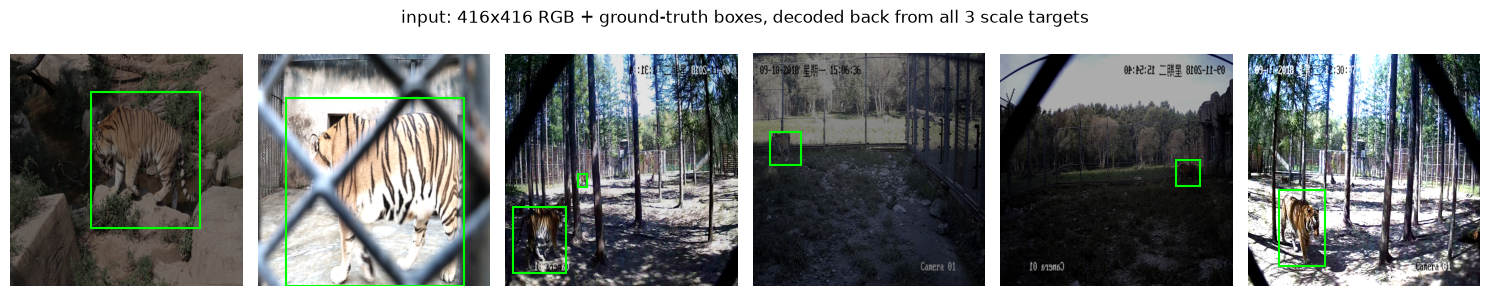

In [9]:
# Look at what we're feeding the network: images + ground-truth boxes decoded across all 3 scales.
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def unnormalize(img):
    """(3,H,W) normalized tensor -> (H,W,3) array in 0..1, for display only."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(unnormalize(xb[i]))
    for x0, y0, x1, y1 in decode_targets_to_boxes([t[i] for t in tb]):
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, edgecolor="lime", linewidth=1.5))
    ax.axis("off")
plt.suptitle("input: 416x416 RGB + ground-truth boxes, decoded back from all 3 scale targets")
plt.tight_layout(); plt.show()


# Section 2 — Helper functions, and why each exists

Same idea as `n5`: a generic toolbox, plus a detection-specific one for turning raw multi-scale
predictions into actual boxes.


In [10]:
def count_params(model):
    """WHY: capacity vs. speed. Spoiler for Section 3: this model has FEWER parameters than n5's,
    despite being deeper -- no giant fully-connected head, everything here is convolutional."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def box_iou(boxes1, boxes2):
    """WHY: the one way to compare two boxes. Corner-format (x0,y0,x1,y1), broadcasts over any
    matching leading dims -- used during NMS and evaluation (not inside the loss this time; the
    loss compares raw t-values directly, see Section 3)."""
    x0 = torch.maximum(boxes1[..., 0], boxes2[..., 0])
    y0 = torch.maximum(boxes1[..., 1], boxes2[..., 1])
    x1 = torch.minimum(boxes1[..., 2], boxes2[..., 2])
    y1 = torch.minimum(boxes1[..., 3], boxes2[..., 3])
    inter = (x1 - x0).clamp(min=0) * (y1 - y0).clamp(min=0)
    area1 = (boxes1[..., 2] - boxes1[..., 0]).clamp(min=0) * (boxes1[..., 3] - boxes1[..., 1]).clamp(min=0)
    area2 = (boxes2[..., 2] - boxes2[..., 0]).clamp(min=0) * (boxes2[..., 3] - boxes2[..., 1]).clamp(min=0)
    return inter / (area1 + area2 - inter + 1e-8)


@torch.no_grad()
def show_shapes(model, size=IMG_SIZE, channels=3):
    """WHY: verify shape flow through the backbone and confirm the 3 routes land on 52/26/13."""
    x = torch.zeros(1, channels, size, size, device=DEVICE)
    print(f"{'input':28} {tuple(x.shape)}")

    hooks = []

    def register(name, module):
        if len(list(module.children())) == 0:
            def hook(_m, _in, out):
                del _m, _in
                if isinstance(out, torch.Tensor):
                    print(f"{name:28} {tuple(out.shape)}")
            hooks.append(module.register_forward_hook(hook))

    for name, module in model.named_modules():
        register(name, module)

    model.eval()
    _ = model(x)

    for h in hooks:
        h.remove()


def plot_history(history):
    """WHY: loss shape tells you if optimization is working; val mAP is the metric that matters."""
    _, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot([h["train_loss"] for h in history], marker="o")
    ax[0].set_title("training loss (sum over ~10.6k cells/image -- naturally bigger than n5's)")
    ax[0].set_xlabel("epoch")
    ax[1].plot([h["val_map"] for h in history], marker="o", color="tab:orange")
    ax[1].set_title("held-out AP@0.5 for Tiger"); ax[1].set_xlabel("epoch")
    plt.tight_layout(); plt.show()


In [11]:
def decode_scale(raw, scale_idx, size=IMG_SIZE):
    """
    One scale's raw model output (N,G,G,A,5+C) -> pixel-space boxes + scores.
    Paper Sec 2.1's equations, applied directly: bx=sigmoid(tx)+cx, by=sigmoid(ty)+cy,
    bw=pw*exp(tw), bh=ph*exp(th). tw/th are clamped before exp() -- an early-training raw
    output can be large, and exp() of a large number is where a runaway loss starts (the same
    class of instability n5 hit with an unconstrained linear head, just one step removed here).
    """
    g = GRID_SIZES[scale_idx]
    stride = size / g
    device = raw.device
    n = raw.shape[0]
    rows = torch.arange(g, device=device).view(1, g, 1, 1).expand(n, g, g, A)
    cols = torch.arange(g, device=device).view(1, 1, g, 1).expand(n, g, g, A)
    anchors = ANCHORS_T[scale_idx * A:(scale_idx + 1) * A].to(device)

    tx, ty, tw, th, tobj = raw[..., 0], raw[..., 1], raw[..., 2], raw[..., 3], raw[..., 4]
    class_logit = raw[..., 5:]

    bx = (torch.sigmoid(tx) + cols) * stride
    by = (torch.sigmoid(ty) + rows) * stride
    bw = anchors[:, 0] * torch.exp(tw.clamp(max=6))
    bh = anchors[:, 1] * torch.exp(th.clamp(max=6))

    boxes = torch.stack([bx - bw / 2, by - bh / 2, bx + bw / 2, by + bh / 2], dim=-1)
    return boxes, torch.sigmoid(tobj), torch.sigmoid(class_logit)


def decode_predictions(preds, conf_thresh=0.2, size=IMG_SIZE):
    """List of 3 raw scale outputs -> per-image (boxes, scores), pooled across all 3 scales and
    all 3 anchors, NOT yet NMS'd. Score = objectness * class prob (paper Eq. 1's logic, adapted
    to logistic classifiers): with C=1 this is "how sure, and is it actually a Tiger."""
    n = preds[0].shape[0]
    per_image_boxes = [[] for _ in range(n)]
    per_image_scores = [[] for _ in range(n)]
    for scale_idx, raw in enumerate(preds):
        boxes, obj, cls = decode_scale(raw, scale_idx, size=size)
        score = obj * cls[..., 0]
        for i in range(n):
            b, s = boxes[i].reshape(-1, 4), score[i].reshape(-1)
            keep = s > conf_thresh
            if keep.any():
                per_image_boxes[i].append(b[keep])
                per_image_scores[i].append(s[keep])
    results = []
    for bi, si in zip(per_image_boxes, per_image_scores):
        if bi:
            results.append((torch.cat(bi), torch.cat(si)))
        else:
            results.append((torch.empty(0, 4), torch.empty(0)))
    return results


def non_max_suppression(boxes, scores, iou_thresh=0.5):
    """Greedy NMS (unchanged from n5): keep the highest-confidence box, drop overlapping ones,
    repeat. More load-bearing here than in n5 -- 3 scales x 3 anchors means more raw candidates
    per object before suppression."""
    order = scores.argsort(descending=True)
    keep = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]
        ious = box_iou(boxes[i].unsqueeze(0), boxes[rest])
        order = rest[ious.squeeze(0) <= iou_thresh]
    return keep


@torch.no_grad()
def mean_average_precision(model, loader, iou_thresh=0.5, conf_thresh=0.2):
    """VOC-style AP for 'Tiger' (11-point interpolation), identical procedure to n5 -- only the
    decode step and the ground-truth source (decode_targets_to_boxes instead of grid_to_boxes)
    changed to account for the multi-scale, anchor-based representation."""
    model.eval()
    all_scores, all_correct = [], []
    n_gt = 0

    for x, targets, ignore in loader:
        preds = model(x.to(DEVICE))
        decoded = decode_predictions([p.cpu() for p in preds], conf_thresh=conf_thresh)
        for b in range(x.shape[0]):
            gt_boxes = decode_targets_to_boxes([t[b] for t in targets])
            n_gt += len(gt_boxes)
            boxes, scores = decoded[b]
            if boxes.numel() == 0:
                continue
            keep = non_max_suppression(boxes, scores, iou_thresh=iou_thresh)
            boxes, scores = boxes[keep], scores[keep]

            matched = [False] * len(gt_boxes)
            order = scores.argsort(descending=True)
            for idx in order:
                box = boxes[idx]
                best_iou, best_j = 0.0, -1
                for j, gt in enumerate(gt_boxes):
                    if matched[j]:
                        continue
                    iou = box_iou(box.unsqueeze(0), torch.tensor(gt).unsqueeze(0)).item()
                    if iou > best_iou:
                        best_iou, best_j = iou, j
                correct = best_iou >= iou_thresh
                if correct:
                    matched[best_j] = True
                all_scores.append(scores[idx].item())
                all_correct.append(correct)

    if n_gt == 0 or not all_scores:
        return 0.0

    order = sorted(range(len(all_scores)), key=lambda i: -all_scores[i])
    tp = torch.tensor([all_correct[i] for i in order], dtype=torch.float32)
    fp = 1 - tp
    tp_cum, fp_cum = torch.cumsum(tp, 0), torch.cumsum(fp, 0)
    recall = tp_cum / n_gt
    precision = tp_cum / (tp_cum + fp_cum)

    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        p = precision[recall >= t]
        ap += (p.max().item() if p.numel() else 0.0) / 11
    return ap


# Section 3 — The architecture

## Bounding boxes: from scratch (v1) to anchor-relative (v3)

`n5` regressed $(x,y,w,h)$ directly. YOLOv3 instead keeps a small set of **anchor** shapes (computed
above by k-means) and predicts an *offset* from the nearest one:

$$
b_x = \sigma(t_x) + c_x \qquad b_y = \sigma(t_y) + c_y \qquad b_w = p_w e^{t_w} \qquad b_h = p_h e^{t_h}
$$

$(c_x, c_y)$ is the cell's top-left corner, $(p_w, p_h)$ the matched anchor's size. The sigmoid on
$t_x, t_y$ keeps the predicted center inside its cell (the paper found a linear offset here
"decreased model stability" — Sec 4); the exponential on $t_w, t_h$ lets the box grow or shrink
from the anchor in either direction without being bounded to $[0,1]$ the way `n5`'s $w,h$ were.

Objectness and class are no longer part of one sum-squared loss term each: **objectness** is a
logistic (sigmoid) regression target, 1 for the best-matching anchor and 0 elsewhere; **class** is
an independent logistic classifier per class, trained with binary cross-entropy instead of softmax
— which matters when a box could plausibly carry more than one label (paper Sec 2.2), though with
C=1 here that distinction doesn't bite.

## Predicting at 3 scales

`n5` had one 7×7 grid, so one cell size had to represent every tiger in the frame — the paper names
this directly as a source of missed small/clustered objects. YOLOv3 predicts independently at
**13×13, 26×26, and 52×52** (for a 416 input): the coarse 13×13 grid (large receptive field →
large anchors) is best for big, close tigers; the fine 52×52 grid (small anchors) for small or
distant ones. The 26×26 and 52×52 heads don't start from nothing — each upsamples the previous
scale's features and **concatenates** them with an earlier, higher-resolution backbone feature map,
so finer scales inherit the coarser scale's semantic understanding plus their own spatial detail
(paper Sec 2.3 — the same idea as a feature pyramid network).

## The backbone: Darknet-53 (here, MiniDarknet53)

| Stage | What it is | Output | Repeats (paper / here) |
|---|---|---|---|
| stem | 3×3 conv, 32 filters | 416×416 | — |
| down1 + stage1 | 3×3 conv /2 + residual blocks, 64ch | 208×208 | 1 / **1** |
| down2 + stage2 | 3×3 conv /2 + residual blocks, 128ch | 104×104 | 2 / **1** |
| down3 + stage3 | 3×3 conv /2 + residual blocks, 256ch | 52×52 → **route (small-object features)** | 8 / **2** |
| down4 + stage4 | 3×3 conv /2 + residual blocks, 512ch | 26×26 → **route (medium)** | 8 / **2** |
| down5 + stage5 | 3×3 conv /2 + residual blocks, 1024ch | 13×13 → **route (large-object features)** | 4 / **1** |

Each residual block is the same 1×1-reduce → 3×3-expand → add-input shortcut from `n4`'s ResNet —
the paper literally describes Darknet-53 as "a hybrid approach between... Darknet-19, and that
newfangled residual network stuff." Downsampling here is a **strided conv**, not max-pooling (a v3
detail that differs from `n5`'s Fast YOLO, which pooled).


In [12]:
class ConvBN(nn.Module):
    """conv -> BN -> leaky ReLU(0.1) -- the Darknet building block (paper Table 1), used
    everywhere in this network: no bare convolutions."""

    def __init__(self, in_ch, out_ch, k=3, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, k, stride, padding=k // 2, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class ResUnit(nn.Module):
    """1x1 reduce -> 3x3 expand -> add input. Darknet-53's shortcut block (paper Table 1) --
    the same residual idea as n4's BasicBlock, just with a bottleneck instead of two 3x3 convs."""

    def __init__(self, channels):
        super().__init__()
        self.conv1 = ConvBN(channels, channels // 2, k=1)
        self.conv2 = ConvBN(channels // 2, channels, k=3)

    def forward(self, x):
        return x + self.conv2(self.conv1(x))


def res_stage(channels, n):
    return nn.Sequential(*[ResUnit(channels) for _ in range(n)])


class MiniDarknet53(nn.Module):
    """Same stride/channel progression as Darknet-53 (paper Table 1), fewer residual repeats
    per stage: [1,2,8,8,4] -> [1,1,2,2,1]. Returns the 3 route feature maps the detection
    heads need, in extraction order (finest first: 52x52, 26x26, 13x13)."""

    def __init__(self):
        super().__init__()
        self.stem = ConvBN(3, 32, k=3)
        self.down1 = ConvBN(32, 64, k=3, stride=2)
        self.stage1 = res_stage(64, 1)
        self.down2 = ConvBN(64, 128, k=3, stride=2)
        self.stage2 = res_stage(128, 1)
        self.down3 = ConvBN(128, 256, k=3, stride=2)
        self.stage3 = res_stage(256, 2)
        self.down4 = ConvBN(256, 512, k=3, stride=2)
        self.stage4 = res_stage(512, 2)
        self.down5 = ConvBN(512, 1024, k=3, stride=2)
        self.stage5 = res_stage(1024, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(self.down1(x))
        x = self.stage2(self.down2(x))
        route_52 = self.stage3(self.down3(x))
        route_26 = self.stage4(self.down4(route_52))
        route_13 = self.stage5(self.down5(route_26))
        return route_52, route_26, route_13


def head_block(in_ch, mid_ch):
    """Alternating 1x1/3x3 convs that process a route before prediction (paper Sec 2.3)."""
    return nn.Sequential(
        ConvBN(in_ch, mid_ch, k=1),
        ConvBN(mid_ch, mid_ch * 2, k=3),
        ConvBN(mid_ch * 2, mid_ch, k=1),
    )


class YOLOv3Mini(nn.Module):
    """3 detection heads, coarse-to-fine, each one route-upsample-concat away from the last --
    paper Sec 2.3's "predictions across scales," end to end."""

    def __init__(self, a=A, c=C):
        super().__init__()
        self.a, self.c = a, c
        out_ch = a * (5 + c)
        self.backbone = MiniDarknet53()

        # scale 0: 13x13, straight off the deepest backbone route
        self.head13 = head_block(1024, 512)
        self.pred13 = nn.Sequential(ConvBN(512, 1024, k=3), nn.Conv2d(1024, out_ch, 1))

        # upsample scale-0 features, concat with route_26 -- paper: "route -2, upsample, concat"
        self.reduce13 = ConvBN(512, 256, k=1)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")
        self.head26 = head_block(256 + 512, 256)
        self.pred26 = nn.Sequential(ConvBN(256, 512, k=3), nn.Conv2d(512, out_ch, 1))

        # upsample scale-1 features, concat with route_52
        self.reduce26 = ConvBN(256, 128, k=1)
        self.head52 = head_block(128 + 256, 128)
        self.pred52 = nn.Sequential(ConvBN(128, 256, k=3), nn.Conv2d(256, out_ch, 1))

    def forward(self, x):
        route_52, route_26, route_13 = self.backbone(x)

        h13 = self.head13(route_13)
        out13 = self.pred13(h13)

        up13 = self.upsample(self.reduce13(h13))
        h26 = self.head26(torch.cat([up13, route_26], dim=1))
        out26 = self.pred26(h26)

        up26 = self.upsample(self.reduce26(h26))
        h52 = self.head52(torch.cat([up26, route_52], dim=1))
        out52 = self.pred52(h52)

        def reshape(t, g):
            n = t.shape[0]
            return t.permute(0, 2, 3, 1).reshape(n, g, g, self.a, 5 + self.c)

        return [reshape(out13, 13), reshape(out26, 26), reshape(out52, 52)]


model = YOLOv3Mini(a=A, c=C).to(DEVICE)
print("trainable parameters:", count_params(model), "(MiniDarknet53 -- compare to n5's Fast YOLO)")


trainable parameters: 28972694 (MiniDarknet53 -- compare to n5's Fast YOLO)


In [13]:
# Watch the tensor flow through the backbone and confirm the 3 routes land on 52/26/13.
show_shapes(model)

with torch.no_grad():
    preds = model(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE))
print("\nthe three (reshaped) prediction tensors:")
for p, g in zip(preds, GRID_SIZES):
    print(f"  scale {g:>2}x{g:<2}: {tuple(p.shape)}")


input                        (1, 3, 416, 416)
backbone.stem.conv           (1, 32, 416, 416)
backbone.stem.bn             (1, 32, 416, 416)
backbone.stem.act            (1, 32, 416, 416)
backbone.down1.conv          (1, 64, 208, 208)
backbone.down1.bn            (1, 64, 208, 208)
backbone.down1.act           (1, 64, 208, 208)
backbone.stage1.0.conv1.conv (1, 32, 208, 208)
backbone.stage1.0.conv1.bn   (1, 32, 208, 208)
backbone.stage1.0.conv1.act  (1, 32, 208, 208)
backbone.stage1.0.conv2.conv (1, 64, 208, 208)
backbone.stage1.0.conv2.bn   (1, 64, 208, 208)
backbone.stage1.0.conv2.act  (1, 64, 208, 208)
backbone.down2.conv          (1, 128, 104, 104)
backbone.down2.bn            (1, 128, 104, 104)
backbone.down2.act           (1, 128, 104, 104)
backbone.stage2.0.conv1.conv (1, 64, 104, 104)
backbone.stage2.0.conv1.bn   (1, 64, 104, 104)
backbone.stage2.0.conv1.act  (1, 64, 104, 104)
backbone.stage2.0.conv2.conv (1, 128, 104, 104)
backbone.stage2.0.conv2.bn   (1, 128, 104, 104)
backbone.

## What one training step actually does

Five lines, same shape as every notebook in this series; only the loss changed.

```python
preds = model(x)                          # 1. FORWARD (3 scales)
loss  = yolov3_loss(preds, targets, ignore)  # 2. MEASURE THE ERROR
optimizer.zero_grad()                     # 3. CLEAR OLD GRADIENTS
loss.backward()                           # 4. BACKWARD  (back-propagation)
optimizer.step()                          # 5. UPDATE THE WEIGHTS
```

**2. Loss.** Unlike `n5`'s single sum-squared loss (paper v1 Eq. 3), YOLOv3 mixes two loss types
per the paper: **sum-squared error** for the 4 box terms (compared directly in $t$-space — no need
to invert a sigmoid for the target the way the literal paper text describes, for the same numerical
reason `n5` needed a sigmoid head), and **binary cross-entropy** for objectness and class (Sec
2.1/2.2). $\lambda_{coord}=5,\ \lambda_{noobj}=0.5$ carry over from v1/v2 (the short v3 tech
report doesn't restate exact weights, but this is the standard Darknet-config convention).


In [14]:
LAMBDA_COORD = 5.0
LAMBDA_NOOBJ = 0.5
bce = nn.BCEWithLogitsLoss(reduction="sum")


def yolov3_loss(preds, targets, ignore):
    """
    preds: list of 3 raw (N,G,G,A,5+C) tensors [13,26,52]. targets/ignore: matching lists from
    encode_targets (batched by DataLoader). For each scale:
      - box x,y: sigmoid(pred) vs. fractional cell-offset target, SSE, positive cells only
      - box w,h: raw pred vs. log(box/anchor) target, SSE, positive cells only (no activation --
        matches the paper's e^t decode, so the loss compares the exponent directly)
      - objectness: BCE, target=1 at positive cells, target=0 at negative (non-ignored) cells
      - class: BCE, positive cells only
    "Ignored" cells (anchor overlaps some box by >0.5 IOU but isn't the best match) contribute
    to none of these terms -- paper Sec 2.1: "it incurs no loss for coordinate or class
    predictions, only objectness" is even stricter for the *assigned* anchor; for near-miss
    anchors we drop objectness too, which is the common practical reading of that rule.
    """
    n = preds[0].shape[0]
    total = preds[0].new_zeros(())
    for raw, tgt, ign in zip(preds, targets, ignore):
        obj_mask = tgt[..., 0] == 1
        noobj_mask = (~obj_mask) & (~ign)

        xy_loss = ((torch.sigmoid(raw[..., 0:2]) - tgt[..., 1:3]) ** 2 * obj_mask.unsqueeze(-1)).sum()
        wh_loss = ((raw[..., 2:4] - tgt[..., 3:5]) ** 2 * obj_mask.unsqueeze(-1)).sum()
        coord_loss = LAMBDA_COORD * (xy_loss + wh_loss)

        obj_loss = bce(raw[..., 4][obj_mask], tgt[..., 0][obj_mask]) if obj_mask.any() else raw.new_zeros(())
        noobj_loss = bce(raw[..., 4][noobj_mask], tgt[..., 0][noobj_mask]) if noobj_mask.any() else raw.new_zeros(())
        class_loss = bce(raw[..., 5:][obj_mask], tgt[..., 5:][obj_mask]) if obj_mask.any() else raw.new_zeros(())

        total = total + coord_loss + obj_loss + LAMBDA_NOOBJ * noobj_loss + class_loss
    return total / n


In [15]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)

x, targets, ignore = next(iter(train_loader))
x = x.to(DEVICE, non_blocking=True)
targets = [t.to(DEVICE, non_blocking=True) for t in targets]
ignore = [t.to(DEVICE, non_blocking=True) for t in ignore]

# Pick one stem kernel weight and watch it change.
w = model.backbone.stem.conv.weight
before = w[0, 0, 0, 0].item()
print("gradient before backward():", w.grad)

preds = model(x)
print("scale shapes:", [tuple(p.shape) for p in preds])

loss = yolov3_loss(preds, targets, ignore)
print("loss:", round(loss.item(), 4), "(sum over ~10.6k cells/image -- see plot_history's note)")

optimizer.zero_grad()
loss.backward()
print("gradient after backward():", round(w.grad[0, 0, 0, 0].item(), 6))

optimizer.step()
print(f"weight: {before:.6f} -> {w[0,0,0,0].item():.6f}  (moved against the gradient)")


gradient before backward(): None
scale shapes: [(16, 13, 13, 3, 6), (16, 26, 26, 3, 6), (16, 52, 52, 3, 6)]
loss: 3645.4709 (sum over ~10.6k cells/image -- see plot_history's note)
gradient after backward(): 0.017835
weight: -0.113989 -> -0.114007  (moved against the gradient)


# Section 4 — Training

Same five lines, now in a loop over epochs. SGD with momentum and weight decay, linear warmup,
two step drops — the same schedule shape as `n5`, for the same reason (no ImageNet pretraining, so
a lower peak LR than the paper's own recipe). Gradient clipping is kept as a safeguard, same as
`n5` — with 3 loss types summed across 3 scales, an early, badly-initialized batch can still
produce a large gradient even with the sigmoid/log parametrization keeping individual terms bounded.


In [16]:
def to_device(tensors, device):
    return [t.to(device, non_blocking=True) for t in tensors]


def fit(model, train_loader, test_loader, epochs=60, lr=1e-3, warmup_epochs=3):
    """Train the model. Returns a history list you can plot."""
    import csv, time
    from pathlib import Path

    log_path = Path("runs") / "n6_yolov3" / "history.csv"
    log_path.parent.mkdir(parents=True, exist_ok=True)

    def log_epoch_csv(rec):
        """Append one epoch's metrics as a CSV row -- survives a KeyboardInterrupt mid-training."""
        write_header = not log_path.exists()
        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rec.keys()))
            if write_header:
                writer.writeheader()
            writer.writerow(rec)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    milestones = [int(epochs * 0.6), int(epochs * 0.85)]
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.1)

    amp_enabled = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = []

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        if epoch <= warmup_epochs:
            warm_lr = lr * epoch / warmup_epochs
            for g in optimizer.param_groups:
                g["lr"] = warm_lr

        model.train()
        running_loss, seen = 0.0, 0

        for x, targets, ignore in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            targets = to_device(targets, DEVICE)
            ignore = to_device(ignore, DEVICE)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=amp_enabled):
                preds = model(x)
                loss = yolov3_loss(preds, targets, ignore)

            scaler.scale(loss).backward()
            if amp_enabled:
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * len(x)
            seen += len(x)

        if epoch > warmup_epochs:
            scheduler.step()

        val_map = mean_average_precision(model, test_loader)
        rec = {
            "epoch": epoch,
            "train_loss": running_loss / seen,
            "val_map": val_map,
            "error_rate": round(100.0 * (1.0 - val_map), 4),
            "epoch_time_sec": round(time.time() - epoch_start, 2),
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(rec)
        log_epoch_csv(rec)
        print(
            f"epoch {epoch:2d}  lr {rec['lr']:.4g}  loss {rec['train_loss']:.4f}  "
            f"val AP@0.5 {rec['val_map']:.3f}  ({rec['epoch_time_sec']:.1f}s)"
        )

    return history


In [19]:
model = YOLOv3Mini(a=A, c=C).to(DEVICE)     # fresh model
history = fit(model, train_loader, test_loader, epochs=30, lr=1e-3)


epoch  1  lr 0.0003333  loss 779.6657  val AP@0.5 0.000  (112.9s)
epoch  2  lr 0.0006667  loss 30.6805  val AP@0.5 0.000  (111.0s)
epoch  3  lr 0.001  loss 22.7081  val AP@0.5 0.000  (104.9s)
epoch  4  lr 0.001  loss 18.6788  val AP@0.5 0.091  (99.3s)
epoch  5  lr 0.001  loss 15.4982  val AP@0.5 0.170  (99.6s)
epoch  6  lr 0.001  loss 13.4660  val AP@0.5 0.259  (102.1s)
epoch  7  lr 0.001  loss 12.0684  val AP@0.5 0.412  (116.4s)
epoch  8  lr 0.001  loss 10.9505  val AP@0.5 0.488  (107.7s)
epoch  9  lr 0.001  loss 9.9836  val AP@0.5 0.499  (106.9s)
epoch 10  lr 0.001  loss 9.3038  val AP@0.5 0.503  (107.0s)
epoch 11  lr 0.001  loss 8.5729  val AP@0.5 0.688  (107.2s)
epoch 12  lr 0.001  loss 7.9313  val AP@0.5 0.604  (108.5s)
epoch 13  lr 0.001  loss 7.3382  val AP@0.5 0.681  (110.4s)
epoch 14  lr 0.001  loss 6.9248  val AP@0.5 0.700  (107.3s)
epoch 15  lr 0.001  loss 6.4711  val AP@0.5 0.704  (113.8s)
epoch 16  lr 0.001  loss 5.9944  val AP@0.5 0.692  (108.4s)
epoch 17  lr 0.001  loss 

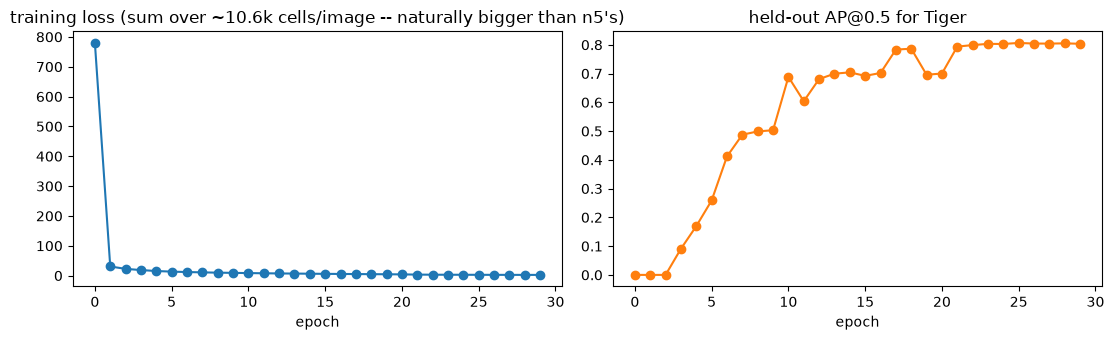

best held-out AP@0.5: 0.8065222014080394
compare against n5's Fast YOLO run on the same val split -- did the anchor + multi-scale
design actually help on frames with several small/clustered tigers, as the paper predicts?


In [20]:
plot_history(history)
print("best held-out AP@0.5:", max(h["val_map"] for h in history))
print("compare against n5's Fast YOLO run on the same val split -- did the anchor + multi-scale")
print("design actually help on frames with several small/clustered tigers, as the paper predicts?")


# Section 5 — Prediction and validation

Same three checks as `n5`: how many boxes survive NMS, the overall AP@0.5, and where the boxes
land. If the multi-scale story is working, look specifically at frames with several tigers —
that's exactly the case `n5`'s single 7×7 scale struggled with.


In [21]:
@torch.no_grad()
def predict(model, x, conf_thresh=0.2, iou_thresh=0.5):
    """Full inference path: forward -> decode across 3 scales -> per-image NMS."""
    model.eval()
    preds = model(x.to(DEVICE))
    decoded = decode_predictions([p.cpu() for p in preds], conf_thresh=conf_thresh)
    results = []
    for boxes, scores in decoded:
        keep = non_max_suppression(boxes, scores, iou_thresh=iou_thresh) if boxes.numel() else []
        results.append((boxes[keep], scores[keep]))
    return results


x, targets, ignore = next(iter(test_loader))
results = predict(model, x[:8])
for i in range(8):
    n_pred = len(results[i][0])
    n_true = int(sum(t[i][..., 0].sum() for t in targets))
    print(f"image {i}: {n_true} true tiger(s)  ->  {n_pred} detected after NMS")


image 0: 2 true tiger(s)  ->  1 detected after NMS
image 1: 1 true tiger(s)  ->  0 detected after NMS
image 2: 4 true tiger(s)  ->  4 detected after NMS
image 3: 2 true tiger(s)  ->  1 detected after NMS
image 4: 1 true tiger(s)  ->  1 detected after NMS
image 5: 2 true tiger(s)  ->  2 detected after NMS
image 6: 1 true tiger(s)  ->  2 detected after NMS
image 7: 2 true tiger(s)  ->  1 detected after NMS


In [22]:
val_map = mean_average_precision(model, test_loader, iou_thresh=0.5, conf_thresh=0.2)
print(f"held-out AP@0.5 for 'Tiger': {val_map:.3f}")
print("floor for comparison: a detector that never fires (predicts nothing) scores AP = 0.000.")


held-out AP@0.5 for 'Tiger': 0.804
floor for comparison: a detector that never fires (predicts nothing) scores AP = 0.000.


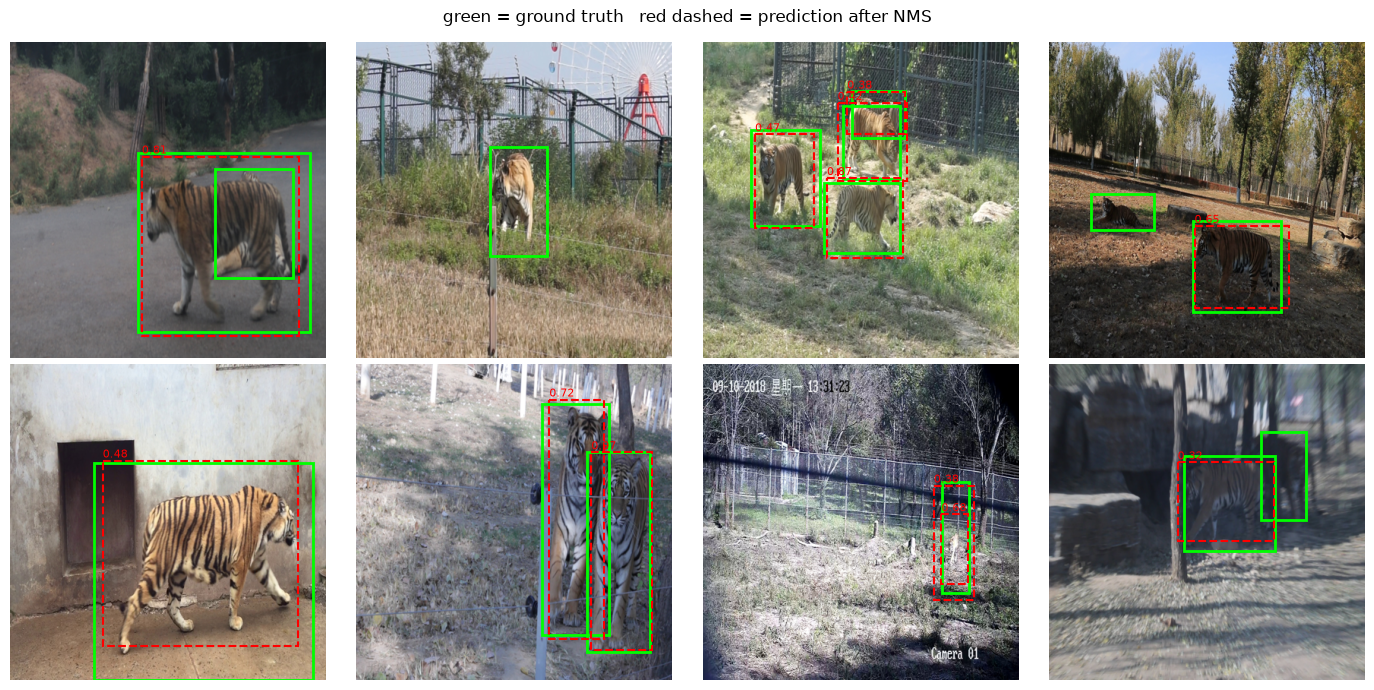

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, i, (boxes, scores) in zip(axes.ravel(), x[:8], range(8), results):
    ax.imshow(unnormalize(img))
    for x0, y0, x1, y1 in decode_targets_to_boxes([t[i] for t in targets]):
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                        fill=False, edgecolor="lime", linewidth=2))
    for (bx0, by0, bx1, by1), s in zip(boxes.tolist(), scores.tolist()):
        ax.add_patch(patches.Rectangle((bx0, by0), bx1 - bx0, by1 - by0,
                                        fill=False, edgecolor="red", linewidth=1.5, linestyle="--"))
        ax.text(bx0, max(by0 - 4, 0), f"{s:.2f}", color="red", fontsize=8)
    ax.axis("off")
plt.suptitle("green = ground truth   red dashed = prediction after NMS")
plt.tight_layout(); plt.show()


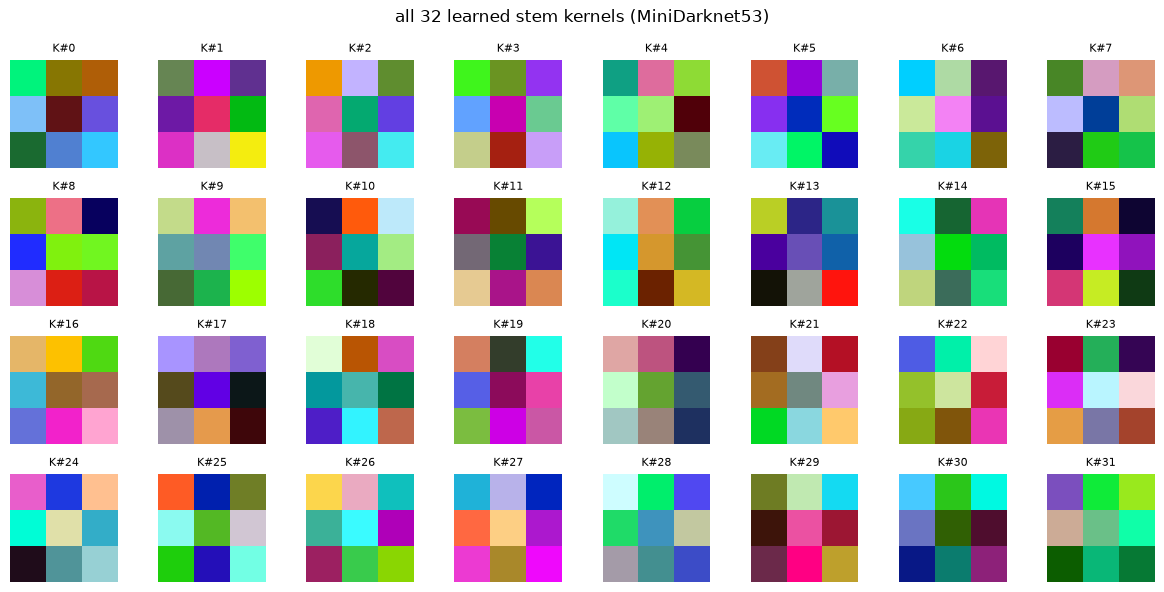

In [24]:
# Visualize the stem kernels. Each 3x3x3 tile is one learned edge/colour detector.
k = model.backbone.stem.conv.weight.detach().cpu()   # (32, 3, 3, 3)
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    tile = k[i].permute(1, 2, 0)
    tile = (tile - tile.min()) / (tile.max() - tile.min() + 1e-8)
    ax.imshow(tile); ax.set_title(f"K#{i}", fontsize=8); ax.axis("off")
plt.suptitle("all 32 learned stem kernels (MiniDarknet53)")
plt.tight_layout(); plt.show()


# Section 6 — Glossary

Terms new to this notebook (see `n5`'s glossary for the ones carried over unchanged: IOU,
non-max suppression, precision/recall, AP/mAP, gradient, backprop, optimizer, epoch/batch,
overfitting, `model.train()`/`eval()`, `zero_grad()`, `no_grad()`).

**Anchor box / dimension prior** — a pre-computed "typical" box shape (from k-means on the
training set) that the network refines instead of regressing a box from nothing.

**Bounding box prior** — same as anchor box; the paper's term.

**k-means with IOU distance** — clustering box shapes using $1-\text{IOU}$ as the distance, so
large and small boxes with the same *shape* error are treated equally (plain Euclidean distance
would favor large boxes).

**Objectness (logistic)** — a single sigmoid output per anchor: is *any* object here, trained with
binary cross-entropy instead of `n5`'s "confidence = IOU" sum-squared target.

**Independent logistic classifier** — one sigmoid per class instead of a softmax over classes;
allows a box to carry more than one label (not exercised here, since C=1).

**Ignore band** — anchors that overlap a ground-truth box by IOU > 0.5 but aren't that box's best
match: excluded from the loss entirely, neither positive nor penalized as negative.

**Residual shortcut** — carried over from `n4`: a block that adds its input back to its output,
making very deep networks (Darknet-53's 53 layers) trainable.

**Strided convolution (as downsampling)** — a stride-2 conv used instead of max-pooling to shrink
the feature map; Darknet-53 has no pooling layers at all.

**Feature pyramid / multi-scale prediction** — detecting at several grid resolutions, each scale
merging its own features with an upsampled, more semantic feature map from a coarser scale.

**Route / upsample / concatenate** — the specific merge operation: take an earlier feature map,
upsample the current one to match its resolution, and stack them channel-wise.

**Darknet-53** — the paper's 53-conv-layer backbone (`MiniDarknet53` here): Darknet-19's
alternating 1×1/3×3 convs plus ResNet-style shortcuts.

**Sum-squared error (SSE) vs. binary cross-entropy (BCE)** — SSE for the 4 box coordinates
(regression: "how far off is the number"), BCE for objectness and class (binary decisions: "is
this true, yes/no" — the natural loss for a sigmoid output).

**AP50 vs. COCO AP** — the paper reports both: AP50 (IOU ≥ 0.5, "the old metric," what this
notebook computes) and COCO's stricter AP averaged over IOU 0.5–0.95. YOLOv3 does well on the
former, worse on the latter — it finds objects reliably but doesn't always localize them tightly
(paper Sec 3).


## Next steps

Change one thing, re-run `fit`, compare held-out AP@0.5 — and against `n5`'s result on the same
val split, since that comparison is the point of building both notebooks:

| Try | What it tells you |
|---|---|
| run `n5` and `n6` back to back on the same `test_loader` images and compare | whether v3's anchors + multi-scale design actually wins on ATRW the way the paper's COCO numbers suggest |
| use the full Darknet-53 repeat counts ([1,2,8,8,4]) instead of MiniDarknet53's | whether the deeper backbone is worth the extra training cost here |
| look specifically at frames with 4+ tigers | whether the 52×52 scale is catching small/clustered tigers that `n5`'s single 7×7 grid missed |
| lower `conf_thresh` / tune `iou_thresh` in NMS | the precision/recall trade-off, same knob as `n5` |
| add real multi-scale *training* (resize the input every few batches, paper Sec 2.5) | whether it improves robustness to tiger scale, beyond the fixed-anchor multi-scale *prediction* already here |
| push `epochs` up, or add ImageNet pretraining for the backbone | how much the from-scratch adaptation (Section 0) is actually costing accuracy |

Change **one** at a time and log the result. That isolates what actually helped.


## Save results

Persist the trained model and validation metrics to `runs/<name>/`, so this run survives a kernel restart and can be compared against the other notebooks later.


In [25]:
# Save the trained model + validation results into runs/n6_yolov3/, so this run isn't lost.
import json
from pathlib import Path

RUN_DIR = Path("runs") / "n6_yolov3"
RUN_DIR.mkdir(parents=True, exist_ok=True)

torch.save({
    "model_state": model.state_dict(),
    "anchors": ANCHORS_FLAT,
    "history": history,
}, RUN_DIR / "model.pt")

with open(RUN_DIR / "metrics.json", "w") as f:
    json.dump({
        "held_out_ap50": val_map,
        "best_val_ap50_during_training": max(h["val_map"] for h in history) if history else None,
        "history": history,
    }, f, indent=2)

print("saved model + metrics to", RUN_DIR.resolve())


saved model + metrics to C:\Users\eeuma\Desktop\PhD Research Codes\5_systematically_move_to_best_architecture\runs\n6_yolov3
